In [17]:
import ast

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [18]:
df = pd.read_csv("../data/experiments_results.csv")
df["fitness_history"] = df["fitness_history"].apply(ast.literal_eval)
df.head()

,dimension,benchmark,algorithm,best_fitness,best_position,fitness_history,execution_time
0,10,Schwefel,PSO (JAX),950.540771,"[-302.5299377441406, -500.0, 420.9538269042969...","[2851.001220703125, 2851.001220703125, 2851.00...",0.009629
1,10,Schwefel,PSO (JAX),572.454590,"[420.97039794921875, 420.953125, -302.48797607...","[3211.964599609375, 3131.50146484375, 2918.508...",0.009490
2,10,Schwefel,PSO (JAX),713.664307,"[420.9374694824219, -302.52606201171875, -500....","[2848.675537109375, 2848.675537109375, 2848.67...",0.009456
3,10,Schwefel,PSO (JAX),1072.013428,"[-500.0, 420.95758056640625, -500.0, 420.97644...","[2657.1904296875, 2657.1904296875, 2657.190429...",0.009363
4,10,Schwefel,PSO (JAX),1070.496338,"[-500.0, -500.0, 420.94866943359375, -302.5317...","[2994.1865234375, 2429.02490234375, 2429.02490...",0.009371


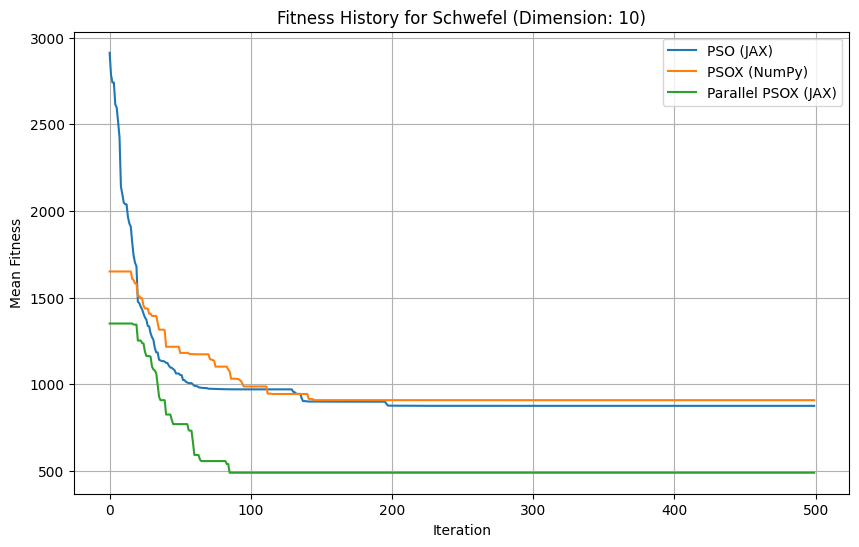

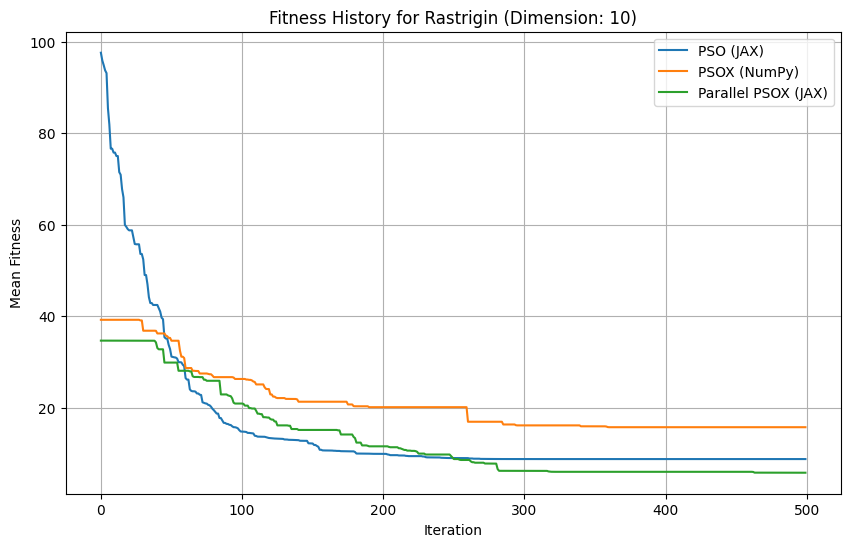

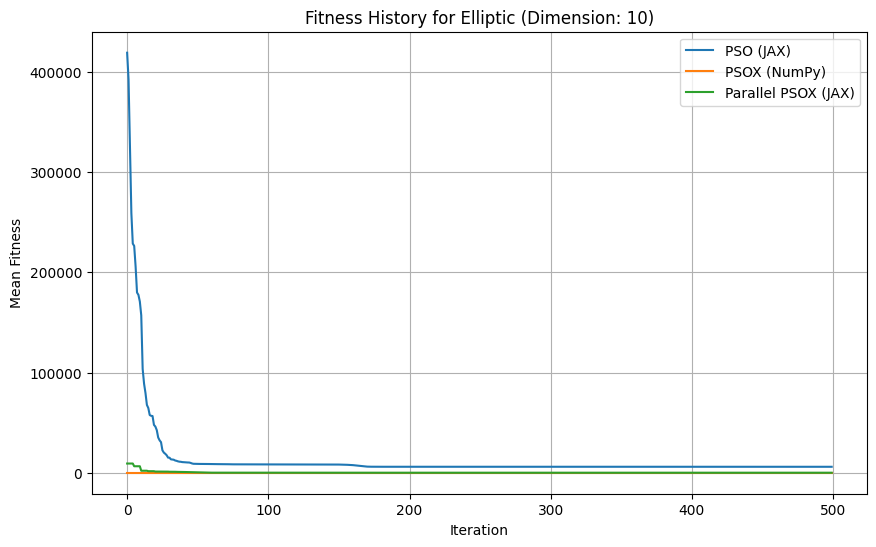

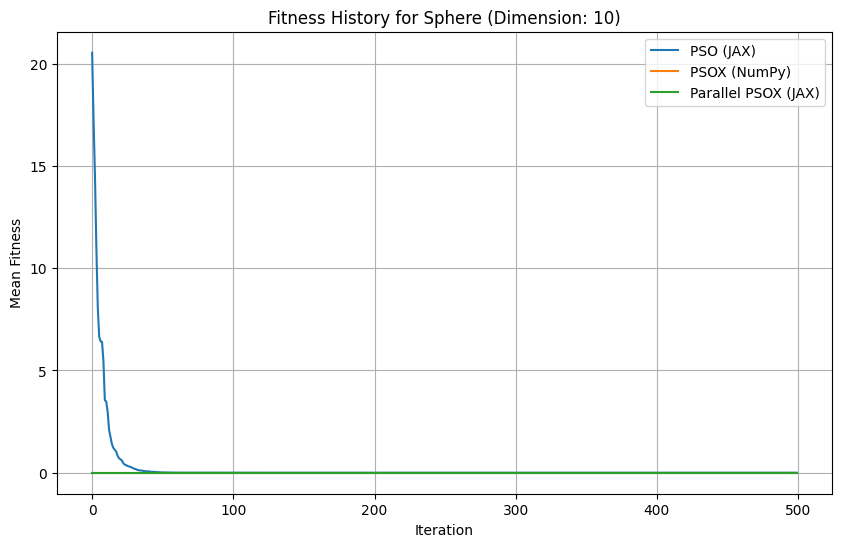

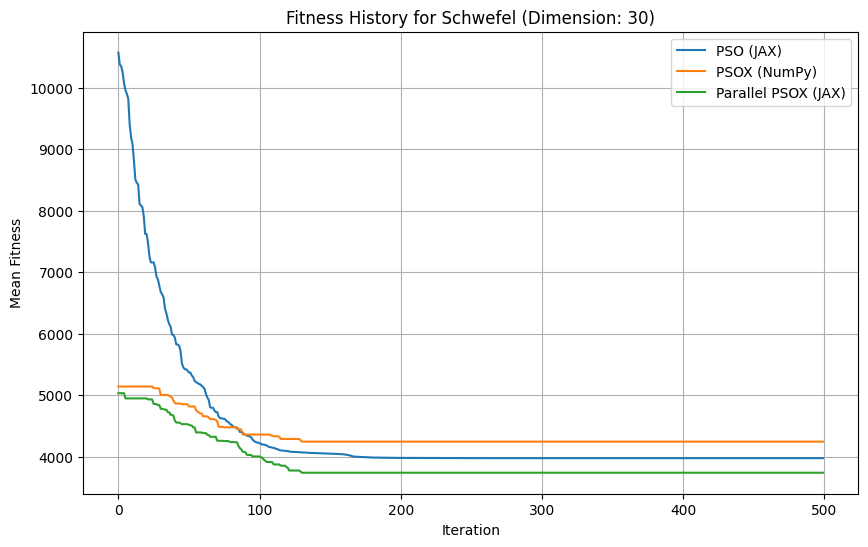

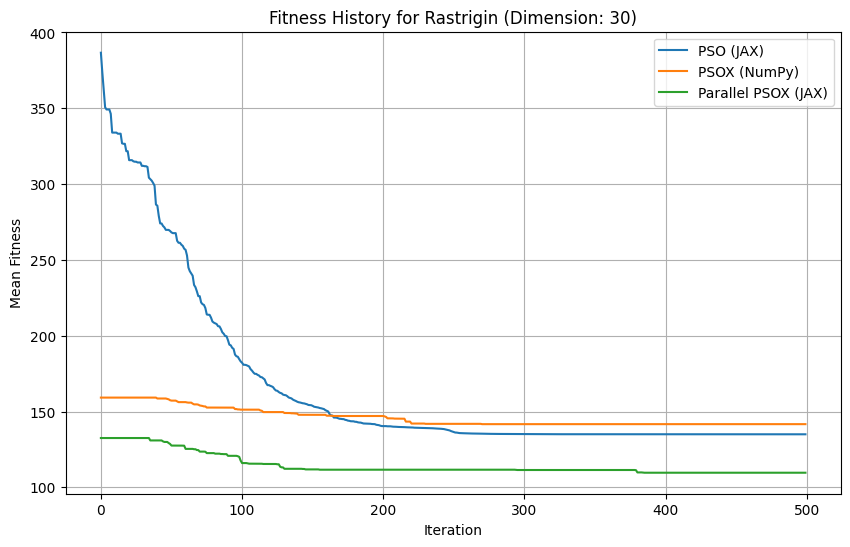

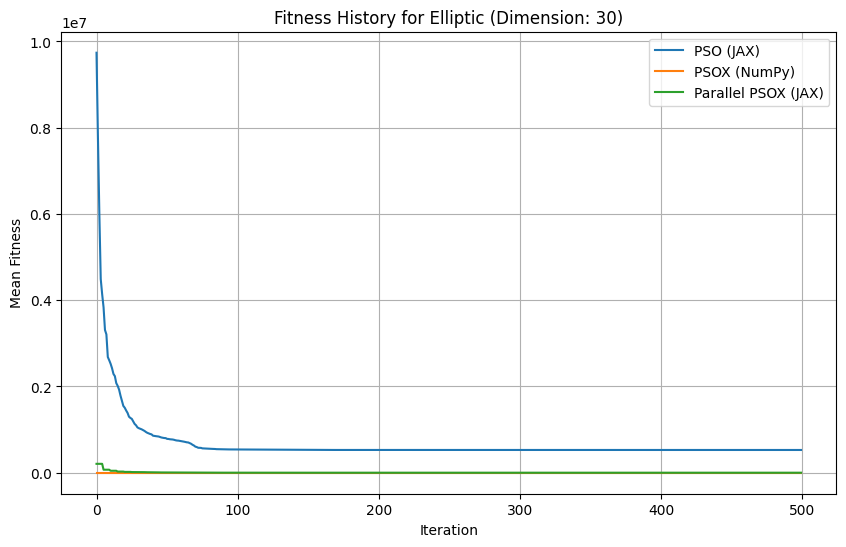

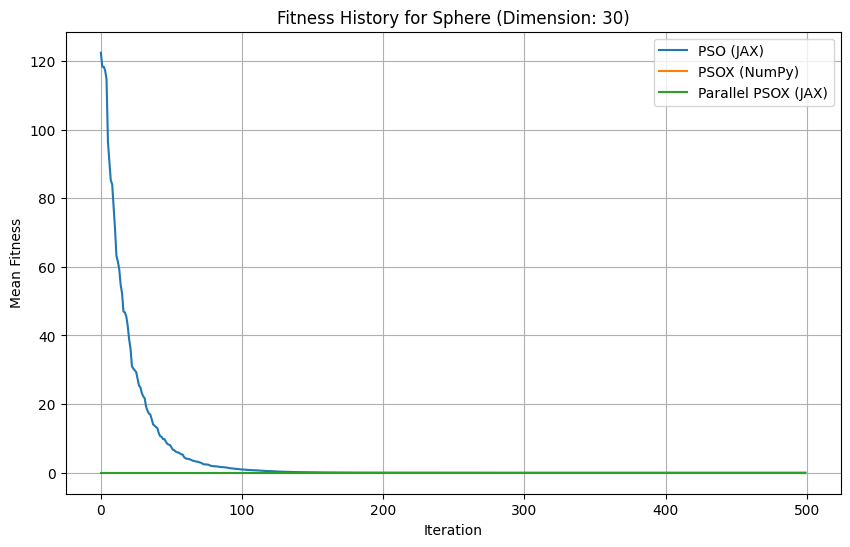

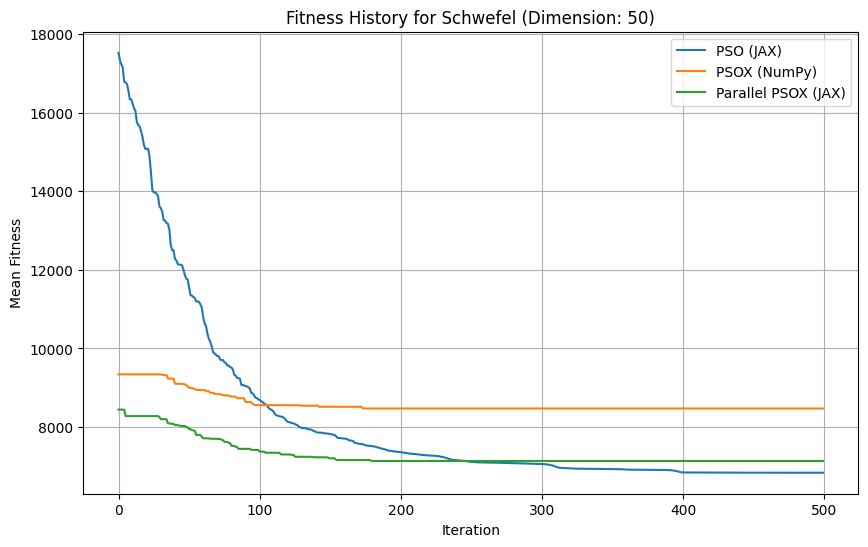

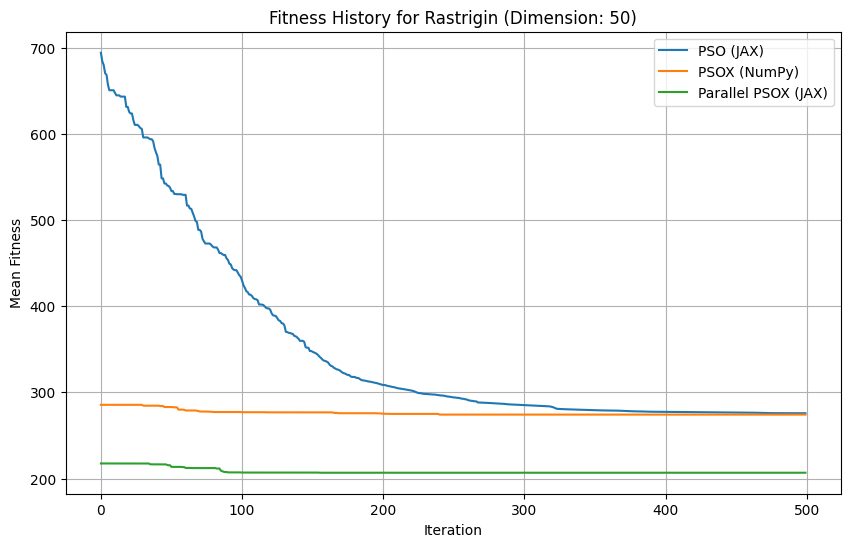

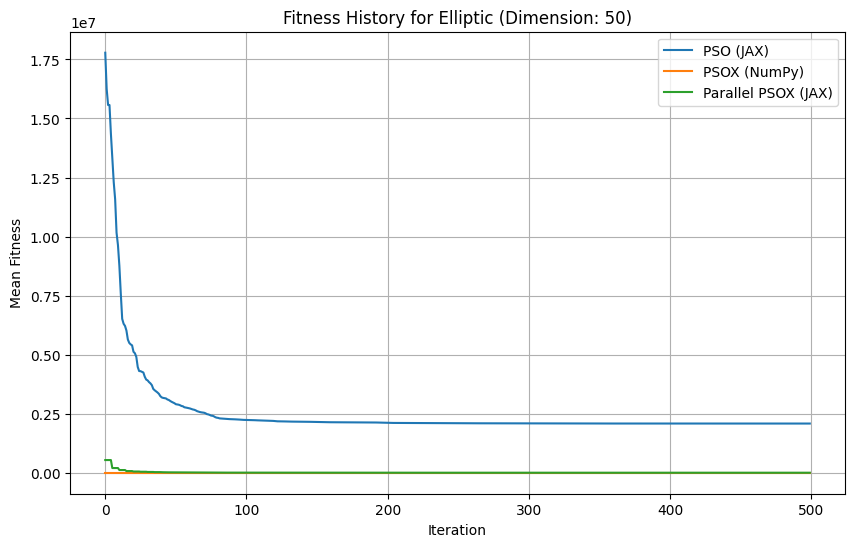

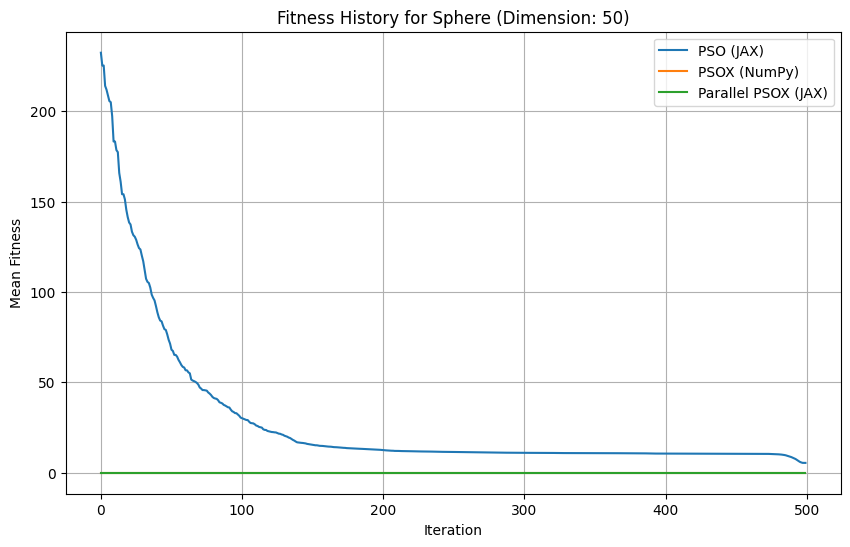

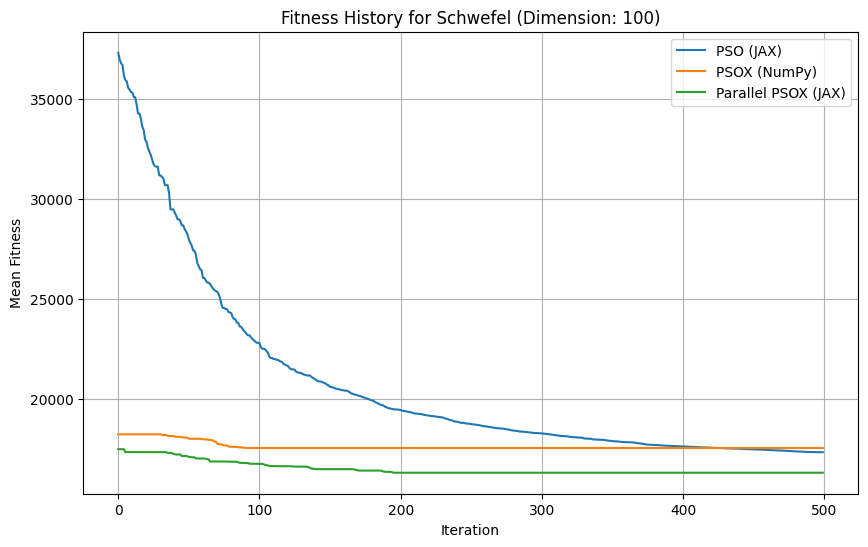

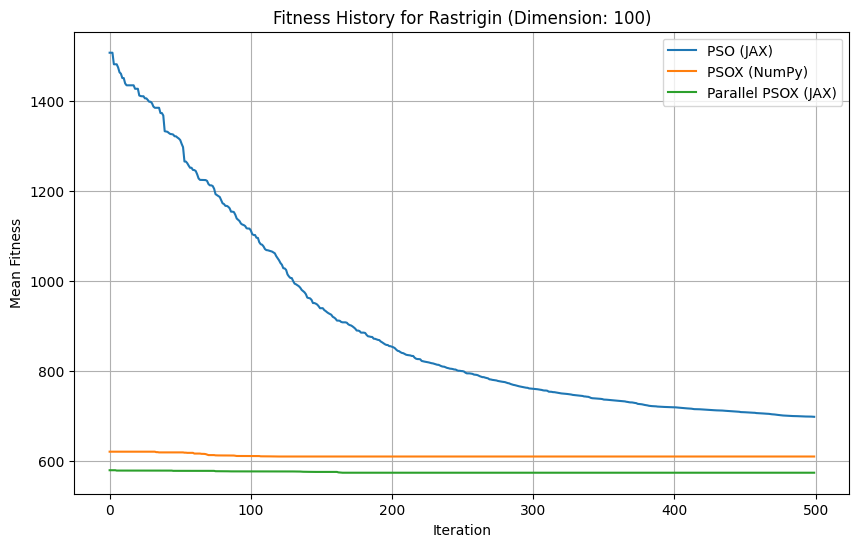

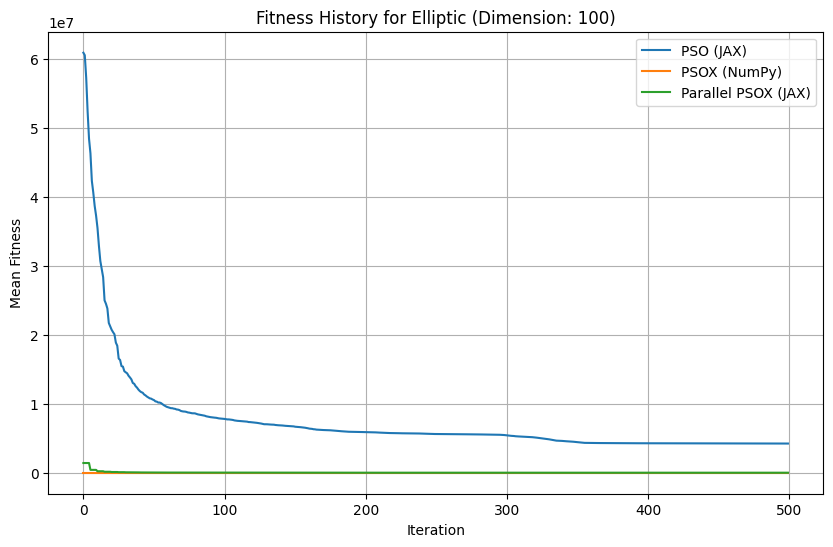

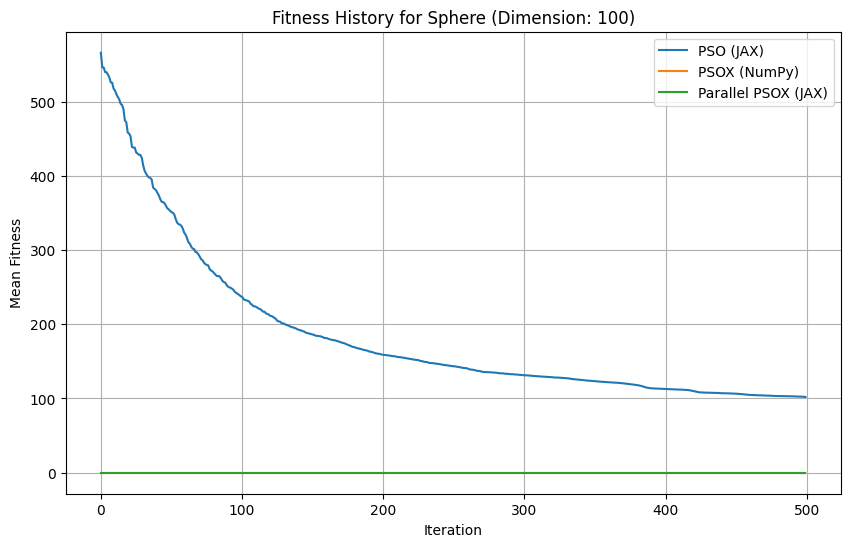

In [19]:
for dimension in df["dimension"].unique():
    for benchmark in df["benchmark"].unique():
        subset = df[(df["dimension"] == dimension) & (df["benchmark"] == benchmark)]
        plt.figure(figsize=(10, 6))
        for algorithm in subset["algorithm"].unique():
            alg_subset = subset[subset["algorithm"] == algorithm]
            fitness_histories = alg_subset["fitness_history"].tolist()
            mean_fitness = pd.DataFrame(fitness_histories).mean()
            plt.plot(mean_fitness, label=algorithm)
        plt.title(f"Fitness History for {benchmark} (Dimension: {dimension})")
        plt.xlabel("Iteration")
        plt.ylabel("Mean Fitness")
        plt.legend()
        plt.grid()
        plt.show()

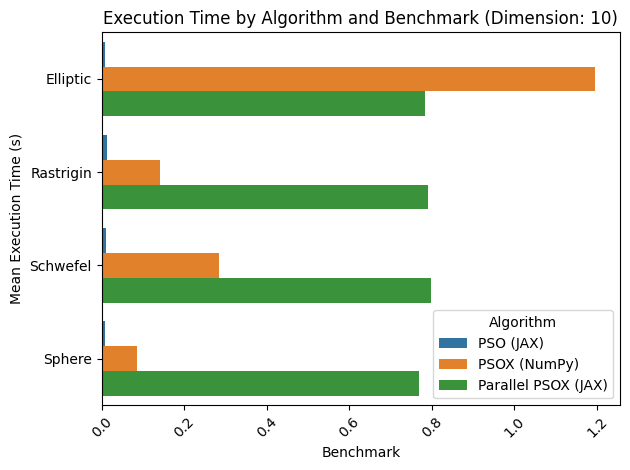

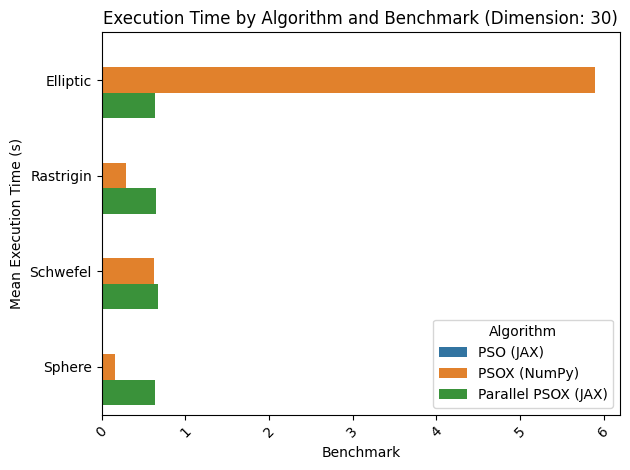

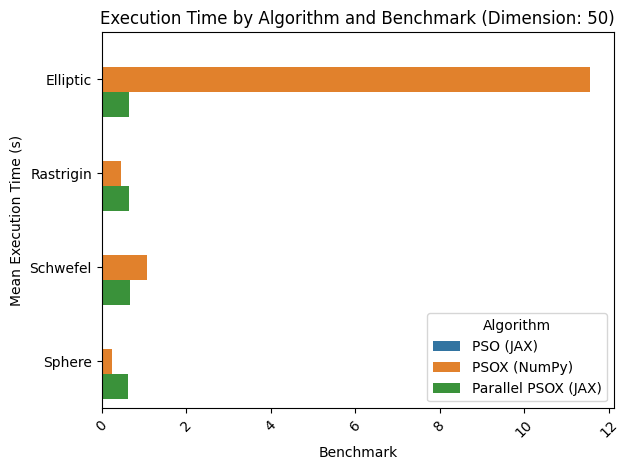

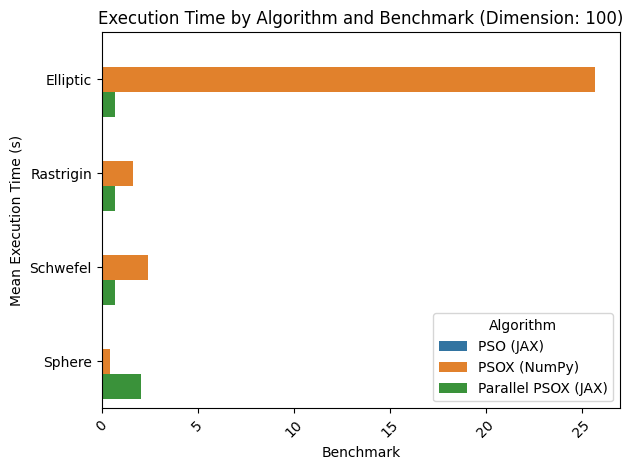

In [20]:
for dimension in df["dimension"].unique():
    mean = (
        df[df["dimension"] == dimension]
        .groupby(["benchmark", "algorithm"])["execution_time"]
        .mean()
    )

    sns.barplot(
        x=mean.values,
        y=mean.index.get_level_values("benchmark"),
        hue=mean.index.get_level_values("algorithm"),
        orient="h",
    )
    plt.title(f"Execution Time by Algorithm and Benchmark (Dimension: {dimension})")
    plt.xlabel("Benchmark")
    plt.ylabel("Mean Execution Time (s)")
    plt.legend(title="Algorithm")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()